In [1]:
import numpy as np
import MDAnalysis as mda
from MDAnalysis.analysis import hydrogenbonds as hbonds
import matplotlib.pyplot as plt
import nglview as nv
import sys
sys.path.append('/home/chemistry/MD/')
import MDcode as MDC
import importlib
import scipy

In [2]:
pwd

'/home/chemistry/MD/G_RNA/traj_220K_normalmodes'

In [3]:
%matplotlib notebook

In [4]:
# Loads just a .gro single-frame file and checks if there are positions and velocities
grofile = 'confout.gro'
xtcfile = "traj.trr"
uframe = mda.Universe(grofile)
print(uframe.trajectory.ts.has_positions)
print(uframe.trajectory.ts.has_velocities)

True
True


In [5]:
# Loads the data
uframe = mda.Universe(grofile)
print(np.shape(uframe.atoms.positions))
print(uframe.trajectory.ts.has_positions)
print(uframe.trajectory.ts.has_velocities)

u = mda.Universe(grofile,xtcfile)

(11558, 3)
True
True


/usr/lib/python3.10/site-packages/MDAnalysis/coordinates/XDR.py:237: UserWarning: Reload offsets from trajectory
 ctime or size or n_atoms did not match
  warnings.warn("Reload offsets from trajectory\n "


In [6]:
# Turn this on if we want to look at a single frame
TOTview = nv.show_mdanalysis(uframe)
TOTview.clear()
# TOTview.add_contact(hydrogen_bond=True) # This slows things down a lot
TOTview.add_representation('licorice',selection='SOL',opacity=0.3)
TOTview.add_representation('ball+stick',selection='RNA')
TOTview.add_representation('ball+stick',selection='NA',color='green',radius=.3)
TOTview.camera='orthographic'

TOTview.center()
# TOTview.add_unitcell()
TOTview.control.rotate([0,1,0,0])
TOTview

NGLWidget()

In [7]:
# Turn this on if we want to look at the trajectory
TOTview = nv.show_mdanalysis(u)
TOTview.clear()
TOTview.add_contact(hydrogen_bond=True) # This slows things down a lot
TOTview.add_representation('licorice',selection='SOL',opacity=0.6)
# TOTview.add_representation('surface',selection='SOL',opacity=0.8)
TOTview.add_representation('ball+stick',selection='RNA')
TOTview.add_representation('ball+stick',selection='NA',color='green',radius=.3)
TOTview.add_representation('ball+stick',selection='1509SOL')
TOTview.add_representation('ball+stick',selection='1510SOL')
TOTview.add_representation('ball+stick',selection='1511SOL')
TOTview.add_representation('ball+stick',selection='1512SOL')
TOTview.add_representation('ball+stick',selection='1513SOL')
TOTview.add_representation('ball+stick',selection='1514SOL')
TOTview.add_representation('ball+stick',selection='1515SOL')
TOTview.add_representation('ball+stick',selection='1516SOL')
TOTview.add_representation('ball+stick',selection='1517SOL')

# # These are H-bonded to O2P at the beginning of this trajectory
# TOTview.add_representation('ball+stick',selection='2297SOL',color='blue')
# TOTview.add_representation('ball+stick',selection='2747SOL',color='blue')
# TOTview.add_representation('ball+stick',selection='2537SOL',color='blue')

# # These are H-bonded to O2P at the end of this trajectory
# TOTview.add_representation('ball+stick',selection='2831SOL',color='green')
# TOTview.add_representation('ball+stick',selection='2784SOL',color='green')
# TOTview.add_representation('ball+stick',selection='2406SOL',color='green')

TOTview.camera='orthographic'
TOTview.center()
# TOTview.add_unitcell()
TOTview.control.rotate([0,1,0,0])
TOTview

NGLWidget(max_frame=50000)

In [8]:
# Specify coordinates we want
O6term = u.select_atoms('name O6')[0]
C6term = u.select_atoms('name C6')[0]

# Extract some coordinates (and time)
O6_position = []
C6_position = []
time = []
for ts in u.trajectory:     # iterate through all frames
    O6_position.append(O6term.position)
    C6_position.append(C6term.position)
    time.append(u.trajectory.time)

<IPython.core.display.Javascript object>


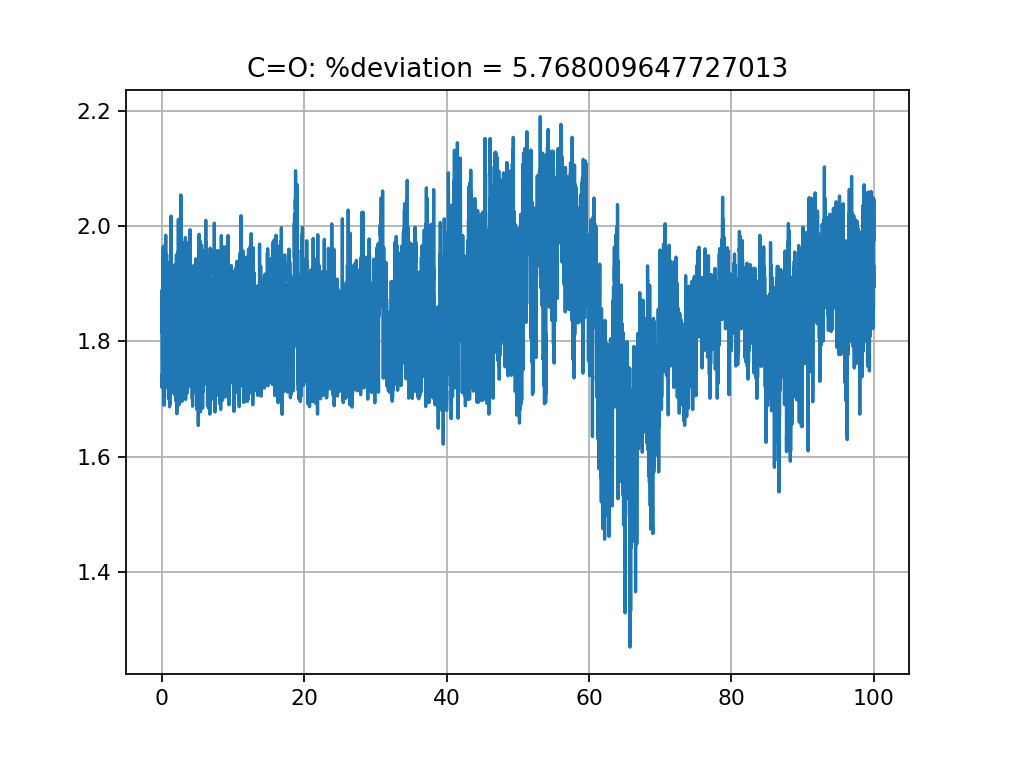

<IPython.core.display.Javascript object>


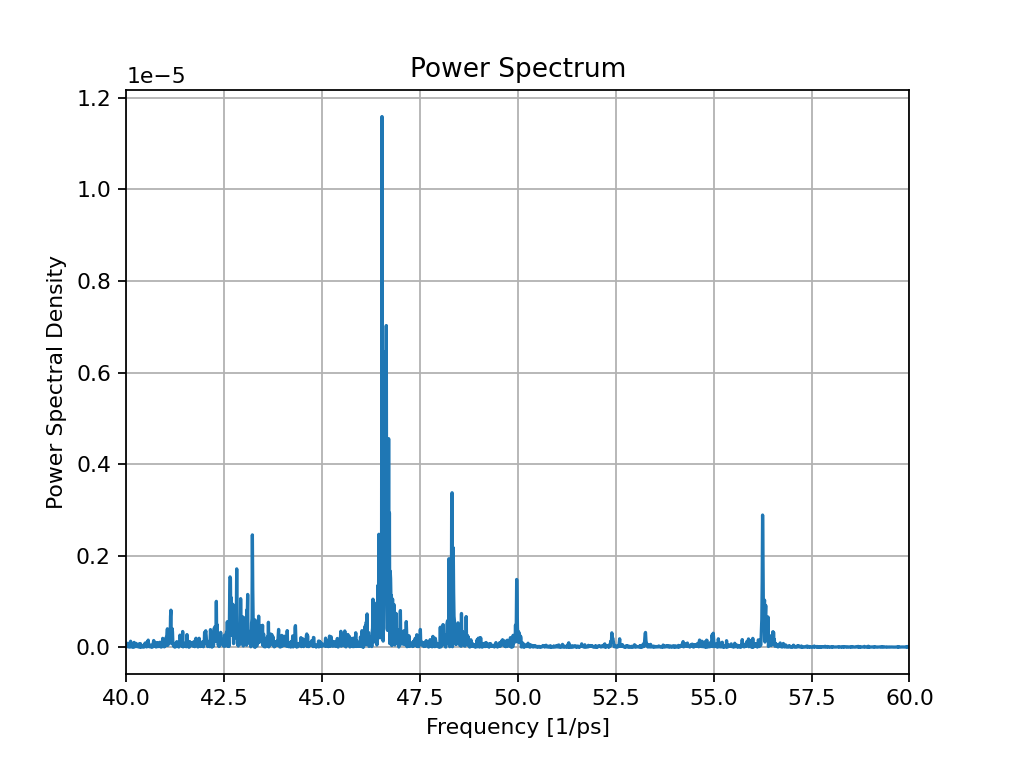

<IPython.core.display.Javascript object>


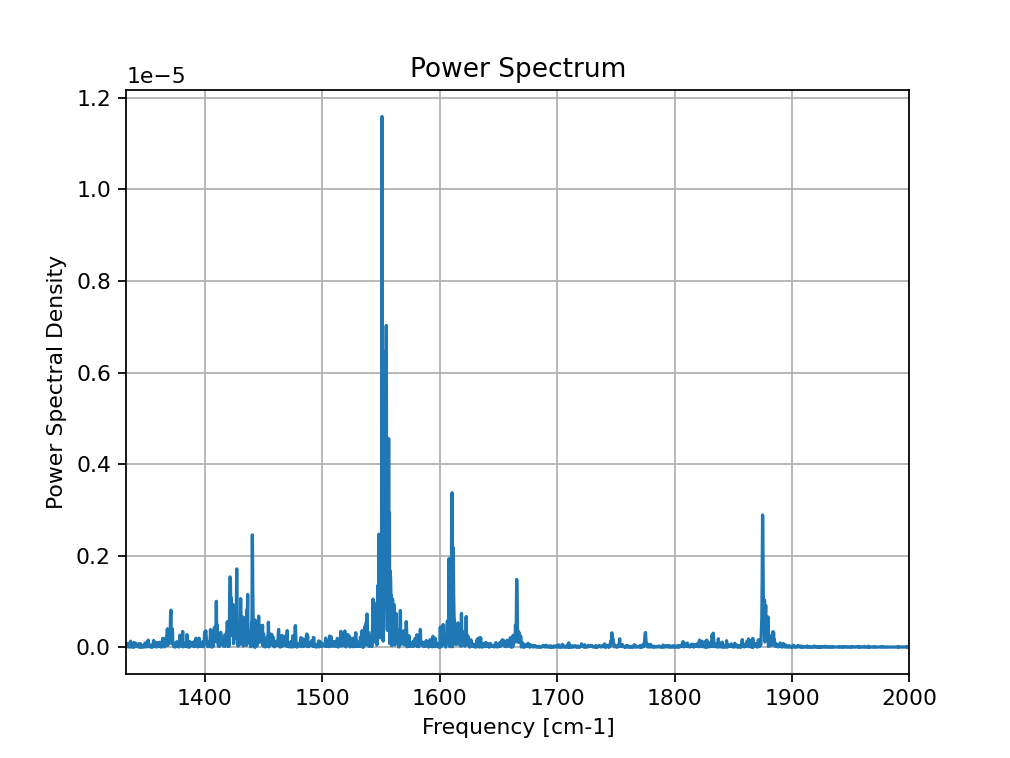

In [9]:
vector_difference = np.array(C6_position)-np.array(O6_position)
carbonyl_distance = np.sum(np.sqrt(vector_difference**2),axis=1)
carbonyl_distance_avg = np.mean(carbonyl_distance)
carbonyl_rms_distance = np.sqrt(np.mean((carbonyl_distance-carbonyl_distance_avg)**2))
percent_deviation = carbonyl_rms_distance/carbonyl_distance_avg*100
plt.figure()
plt.plot(time,carbonyl_distance)
title = 'C=O: '+'%deviation = '+str(percent_deviation)
plt.title(title)
plt.grid(True)


# Compute FFT
dt = time[1]-time[0]  # Sampling interval
N = len(carbonyl_distance)
Y = np.fft.fft(carbonyl_distance) / N  # Normalize
f = np.fft.fftfreq(N, dt)  # Frequency vector
f_Hz = f * 1e12
c = 3.0e10
nubar = f_Hz/c
xlim_inverseps = np.array([40,60])
xlim_wavenum = xlim_inverseps * 1e12 / c

# Calculate power spectral density
Pyy = 2 * np.abs(Y)**2

# Plotting
plt.figure()
ixstart = 1500
plt.plot(f[ixstart:N//2], Pyy[ixstart:N//2])  # Plot only positive frequencies
plt.xlabel('Frequency [1/ps]')
plt.ylabel('Power Spectral Density')
plt.title('Power Spectrum')
plt.xlim(xlim_inverseps)
plt.grid()

plt.figure()
plt.plot(nubar[ixstart:N//2], Pyy[ixstart:N//2])  # Plot only positive frequencies
plt.xlabel('Frequency [cm-1]')
plt.ylabel('Power Spectral Density')
plt.title('Power Spectrum')
plt.xlim(xlim_wavenum)
plt.grid()